In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"D:\Python_ML_projects\Logestic_Regression\HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
df.shape

(14999, 10)

In [9]:
left = df[df["left"]==1]
left.shape

(3571, 10)

In [10]:
retained = df[df["left"]==0]
retained.shape

(11428, 10)

In [11]:
(3571/14999)*100

23.80825388359224

In [15]:
df.groupby("left").mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


# Salary on retention

<Axes: xlabel='salary'>

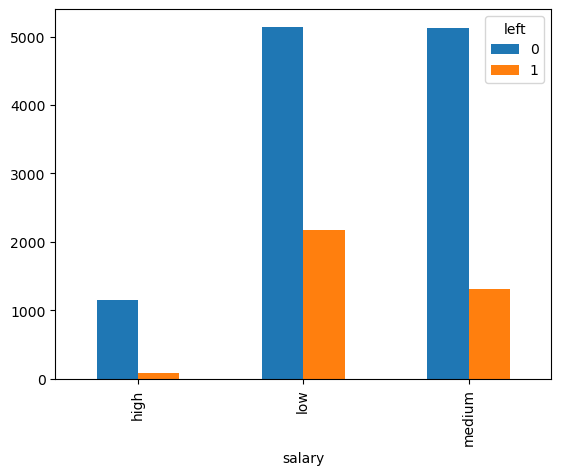

In [17]:
pd.crosstab(df.salary,df.left).plot(kind="bar")            # Crosstab means taking 2 columns and keeping side by side and reading

In [19]:
df = df.rename(columns={"sales": "Department"})

In [21]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


<Axes: xlabel='Department'>

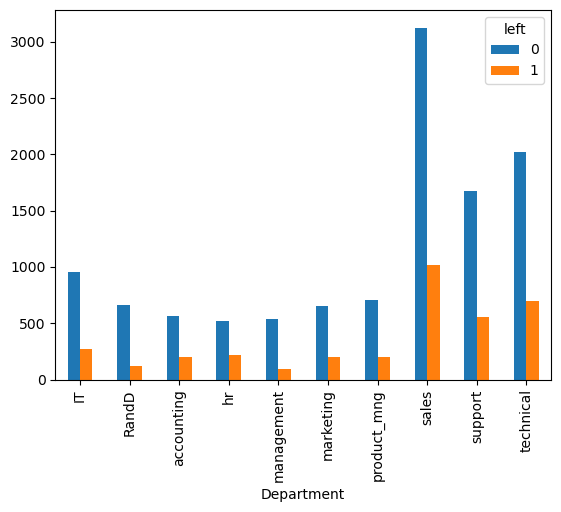

In [22]:
pd.crosstab(df.Department,df.left).plot(kind="bar") 

In [23]:
df.head(1)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low


In [26]:
subdf = df[["satisfaction_level","average_montly_hours","promotion_last_5years","salary"]]
subdf.head(5)

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [34]:
salary_dummies = pd.get_dummies(subdf.salary,prefix="salary").astype(int)

In [35]:
df_with_dummies = pd.concat([subdf,salary_dummies],axis="columns")

In [36]:
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,0,1,0
1,0.80,262,0,medium,0,0,1
2,0.11,272,0,medium,0,0,1
3,0.72,223,0,low,0,1,0
4,0.37,159,0,low,0,1,0


In [37]:
df_with_dummies.drop(columns="salary",inplace=True)

In [39]:
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,0,1,0
1,0.80,262,0,0,0,1
2,0.11,272,0,0,0,1
3,0.72,223,0,0,1,0
4,0.37,159,0,0,1,0


In [40]:
X = df_with_dummies

In [41]:
X.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,0,1,0
1,0.80,262,0,0,0,1
2,0.11,272,0,0,0,1
3,0.72,223,0,0,1,0
4,0.37,159,0,0,1,0


In [42]:
y = df.left
y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20)

In [45]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [47]:
model.fit(X_train,y_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [49]:
X_test[12:13]

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
8488,0.66,162,0,0,1,0


In [50]:
y_test[12:13]

8488    0
Name: left, dtype: int64

In [48]:
model.predict(X_test[12:13])

array([0], dtype=int64)

In [51]:
model.score(X_test,y_test)

0.77

In [52]:
y_pred = model.predict(X_test)

In [54]:
y_pred

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

In [57]:
from sklearn.metrics import classification_report

In [60]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2294
           1       0.52      0.25      0.33       706

    accuracy                           0.77      3000
   macro avg       0.66      0.59      0.60      3000
weighted avg       0.74      0.77      0.74      3000



In [61]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [62]:
logit_roc_auc =  roc_auc_score(y_test,y_pred)

In [63]:
logit_roc_auc 

0.5883015428843812

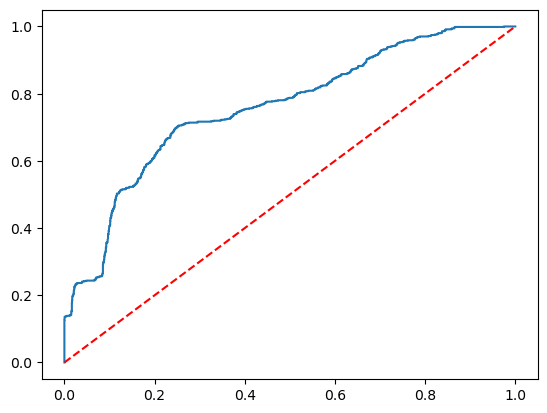

In [67]:
fpr,tpr,tresholds = roc_curve(y_test,model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr,tpr,label = "Logistic Regression" % logit_roc_auc)
plt.plot([0,1],[0,1],"r--")